# Data Collection, 360 Feature Processing & Exploratory Data Analysis (EDA)



## Step 1: Environment Setup & Library Imports

In [1]:
# Install required packages if not already installed
# %pip install -q --user statsbombpy mplsoccer seaborn pandas numpy matplotlib scipy scikit-learn shap

import os
import sys
import json
import math
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from statsbombpy import sb

warnings.filterwarnings('ignore')

# Set professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Robust root directory resolution (works whether running from root or inside Notebooks/)
cwd = os.getcwd()
if os.path.basename(cwd) == 'Notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = os.path.abspath(cwd)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"✓ Environment initialized. Using project root at: {PROJECT_ROOT}")


✓ Environment initialized. Using project root at: /Users/prova/Documents/cse490d-project


## Step 2: Pitch Drawing Utility (Standard 120 x 80 Yard Coordinate System)

In [2]:
def draw_pitch(ax, pitch_color='#f8f9fa', line_color='#333333'):
    """Draw a standard StatsBomb pitch (120 x 80 yards)"""
    ax.set_facecolor(pitch_color)
    # Pitch boundary
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color=line_color, lw=1.5)
    # Halfway line
    ax.plot([60, 60], [0, 80], color=line_color, lw=1.2)
    # Center circle & spot
    center_circle = plt.Circle((60, 40), 10, color=line_color, fill=False, lw=1.2)
    center_spot = plt.Circle((60, 40), 0.8, color=line_color)
    ax.add_patch(center_circle)
    ax.add_patch(center_spot)
    
    # Left Penalty Area & 6-yard box
    ax.plot([0, 18, 18, 0], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([0, 6, 6, 0], [30, 30, 50, 50], color=line_color, lw=1.0)
    left_pen_spot = plt.Circle((12, 40), 0.8, color=line_color)
    ax.add_patch(left_pen_spot)
    left_arc = patches.Arc((12, 40), 20, 20, angle=0, theta1=308, theta2=52, color=line_color, lw=1.2)
    ax.add_patch(left_arc)
    
    # Right Penalty Area & 6-yard box
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([120, 114, 114, 120], [30, 30, 50, 50], color=line_color, lw=1.0)
    right_pen_spot = plt.Circle((108, 40), 0.8, color=line_color)
    ax.add_patch(right_pen_spot)
    right_arc = patches.Arc((108, 40), 20, 20, angle=0, theta1=128, theta2=232, color=line_color, lw=1.2)
    ax.add_patch(right_arc)
    
    # Goals
    ax.plot([-2, 0, 0, -2], [36, 36, 44, 44], color=line_color, lw=1.5)
    ax.plot([122, 120, 120, 122], [36, 36, 44, 44], color=line_color, lw=1.5)
    
    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 85)
    ax.set_aspect('equal')
    ax.axis('off')

print("✓ Pitch drawing engine defined.")


✓ Pitch drawing engine defined.


## Step 3: Positional 360 Geometry Feature Extraction
Computes:
* **Distance & Angle to Goal**
* **Closest Opponent Proximity** ($d_{\text{opp\_min}}$)
* **High-Intensity Defensive Pressure Rings** ($<3\text{m}$ and $<5\text{m}$)
* **Defenders in Goal Cone** ($N_{\text{cone}}$) via Barycentric coordinates
* **Forward Passing Options** ($N_{\text{forward\_opt}}$).
* **Pipeline-compatible name parsing and tactical position mappings** for raw StatsBomb fields.


In [3]:
def extract_name(val):
    """Safely extract 'name' from dict, stringified dict, or raw value."""
    if isinstance(val, dict):
        return val.get('name', '')
    if isinstance(val, str):
        m = re.search(r"'name':\s*'([^']+)'", val)
        if m:
            return m.group(1)
        return val
    return str(val) if pd.notna(val) else ''

def role_group(pos):
    """Broad role mapping shared with the Aura Score pipeline."""
    p = str(pos).lower()
    if any(m in p for m in ['midfield', 'mid']):
        return 'Midfielder'
    if any(f in p for f in ['forward', 'wing', 'striker']):
        return 'Forward'
    if any(d in p for d in ['back', 'keeper', 'defense']):
        return 'Defender/GK'
    return 'Other'

def map_position_group(pos):
    """8-class tactical position grouping shared with the Aura Score pipeline."""
    if pd.isna(pos):
        return 'Other'
    p = str(pos).strip()
    if 'Goalkeeper' in p or 'Keeper' in p:
        return 'GK'
    if 'Center Back' in p:
        return 'CB'
    if 'Back' in p or 'Wing Back' in p:
        return 'FB/WB'
    if 'Defensive Midfield' in p:
        return 'DM'
    if 'Attacking Midfield' in p or 'Wing' in p:
        return 'AM/W'
    if 'Midfield' in p:
        return 'CM'
    if 'Forward' in p or 'Striker' in p:
        return 'ST'
    return 'Other'

def _calc_dist_angle(x, y, gx=120, gy=40):
    dx, dy = gx - x, gy - y
    return math.sqrt(dx**2 + dy**2), (math.atan2(abs(dy), dx) if dx > 0 else 0.0)

def process_360_frame_features(frame_df, event_x, event_y, end_x=np.nan, end_y=np.nan, is_complete=True):
    """
    Extract high-dimensional positional features from a StatsBomb 360 freeze frame.
    Calculates spatial density, pressure rings, goal cone defenders, and tactical line-breaking penetration.
    """
    if frame_df is None or frame_df.empty:
        return {
            'has_360': False,
            'teammates_visible': np.nan,
            'opponents_visible': np.nan,
            'total_visible': np.nan,
            'closest_opp_dist': np.nan,
            'closest_teammate_dist': np.nan,
            'opponents_within_3m': np.nan,
            'opponents_within_5m': np.nan,
            'defenders_in_goal_cone': np.nan,
            'forward_passing_options': np.nan,
            'opponents_eliminated': np.nan,
            'line_breaking_pass': False,
            'pressing_intensity': np.nan,
            'defensive_cover': np.nan,
            'central_corridor': np.nan,
            'spatial_superiority': np.nan,
            'short_combo_options': np.nan
        }
        
    teammates = frame_df[frame_df['teammate'] == True]
    opponents = frame_df[frame_df['teammate'] == False]
    
    n_teammates = len(teammates)
    n_opponents = len(opponents)
    total_tracked = len(frame_df)
    
    # 1. Proximity to closest opponent
    opp_dists = []
    for _, opp in opponents.iterrows():
        loc = opp.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            d = math.sqrt((loc[0] - event_x)**2 + (loc[1] - event_y)**2)
            opp_dists.append(d)
            
    closest_opp = min(opp_dists) if opp_dists else np.nan
    opp_3m = sum(1 for d in opp_dists if d <= 3.28) # 3 meters in yards
    opp_5m = sum(1 for d in opp_dists if d <= 5.46) # 5 meters in yards
    
    # 2. Proximity to closest teammate
    team_dists = []
    for _, tm in teammates.iterrows():
        loc = tm.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            d = math.sqrt((loc[0] - event_x)**2 + (loc[1] - event_y)**2)
            team_dists.append(d)
            
    closest_team = min(team_dists) if team_dists else np.nan
    
    # 3. Defenders in goal cone (between ball and goal mouth y: 30 to 50)
    in_cone = 0
    for _, opp in opponents.iterrows():
        loc = opp.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            if loc[0] > event_x and (30.0 <= loc[1] <= 50.0):
                in_cone += 1
                
    # 4. Forward progressive passing options (teammates located >= 2 yards ahead)
    forward_options = 0
    for _, tm in teammates.iterrows():
        loc = tm.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            if loc[0] > (event_x + 2.0):
                forward_options += 1
                
    # 5. True Line-Breaking Defensive Bypass:
    # An opponent is outplayed/bypassed if the ball moves forward past them (event_x < opp_x < end_x)
    opponents_bypassed = 0
    if is_complete and not np.isnan(end_x) and end_x > (event_x + 2.0):
        y_min = min(event_y, end_y) - 6.0 if not np.isnan(end_y) else event_y - 10.0
        y_max = max(event_y, end_y) + 6.0 if not np.isnan(end_y) else event_y + 10.0
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if (event_x < loc[0] < end_x) and (y_min <= loc[1] <= y_max):
                    opponents_bypassed += 1
    elif not np.isnan(end_x) and end_x > (event_x + 4.0):
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if event_x < loc[0] < end_x:
                    opponents_bypassed += 1
                    

    # ─── 5 New Midfielder-Specific Features ──────────────────────────────────────
    #
    # PRESSING INTENSITY: sum of 1/d for every opponent within 10 yards.
    # Unlike the binary under_pressure flag, this is continuous and captures
    # COLLECTIVE pressure. Modrić at 1.5m from one opponent AND 2.5m from another
    # gets full credit; a striker in open space with closest opp at 8m gets near zero.
    pressing_intensity = (
        sum(1.0 / max(d, 0.5) for d in opp_dists if d <= 10.0)
        if opp_dists else 0.0
    )

    # DEFENSIVE COVER: teammates strictly BEHIND the ball carrier (>2 yds behind).
    # Captures the structural depth behind the action — essential for disciplined
    # midfield buildup. High cover means the team is structured, not just hoofing it.
    defensive_cover = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple, np.ndarray)) and len(tm['location']) >= 2
        and tm['location'][0] < event_x - 2
    )

    # CENTRAL CORRIDOR: flag for actions in the central channel (y in [22, 58] yards).
    # Modrić, Busquets, De Bruyne all operate predominantly in this vertical band.
    # Actions here carry highest catalytic potential — they connect both flanks.
    central_corridor = int(22.0 <= event_y <= 58.0)

    # SPATIAL SUPERIORITY: local teammate count minus opponent count within 8m radius.
    # Positive = local overload (player has created or found a pocket of space).
    # Negative = underloaded pocket (high-risk, high-reward situation).
    _r8 = 8.0
    _local_tm = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple, np.ndarray)) and len(tm['location']) >= 2
        and math.sqrt((tm['location'][0]-event_x)**2 + (tm['location'][1]-event_y)**2) <= _r8
    )
    _local_op = sum(
        1 for _, opp in opponents.iterrows()
        if isinstance(opp.get('location'), (list, tuple, np.ndarray)) and len(opp['location']) >= 2
        and math.sqrt((opp['location'][0]-event_x)**2 + (opp['location'][1]-event_y)**2) <= _r8
    )
    spatial_superiority = _local_tm - _local_op

    # SHORT COMBINATION OPTIONS: teammates within ~5 yards (5.46 = 5m).
    # Captures triangle play, wall passes, quick one-twos. Elite central midfielders
    # like Modrić almost always have 1-2 such nearby options available even when pressed.
    short_combo_options = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple, np.ndarray)) and len(tm['location']) >= 2
        and math.sqrt((tm['location'][0]-event_x)**2 + (tm['location'][1]-event_y)**2) <= 5.46
    )

    is_line_breaking = opponents_bypassed >= 2
    
    return {
        'has_360': True,
        'teammates_visible': n_teammates,
        'opponents_visible': n_opponents,
        'total_visible': total_tracked,
        'closest_opp_dist': round(closest_opp, 3) if not np.isnan(closest_opp) else np.nan,
        'closest_teammate_dist': round(closest_team, 3) if not np.isnan(closest_team) else np.nan,
        'opponents_within_3m': opp_3m,
        'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': in_cone,
        'forward_passing_options': forward_options,
        'opponents_eliminated': opponents_bypassed,
        'line_breaking_pass': is_line_breaking,
        'pressing_intensity': round(pressing_intensity, 4),
        'defensive_cover': defensive_cover,
        'central_corridor': central_corridor,
        'spatial_superiority': spatial_superiority,
        'short_combo_options': short_combo_options
    }

## Step 4: Full 115-Match Dataset Extraction (WC2022 + Euro2020; Euro2024 Held-Out)
Connects to the StatsBomb Open Data API and downloads the complete 115-match training corpus (FIFA World Cup 2022: 64 matches + UEFA Euro 2020: 51 matches). UEFA Euro 2024 (30 matches) is retained only as the held-out tournament metadata. If `full_training_events_360.csv` already exists locally, it loads directly.

*Note: passive events (for example Starting XI, Half Start, Substitution, and Ball Receipt*) are retained here for complete dataset characterisation. The Aura Score pipeline removes them before feature engineering and model training.*


In [4]:
metadata_csv_path = os.path.join(DATA_DIR, 'matches_metadata.csv')
processed_csv_path = os.path.join(DATA_DIR, 'full_training_events_360.csv')

# Match metadata supports Figure 1 and supplies tournament labels if a full rebuild is needed.
if os.path.exists(metadata_csv_path):
    print(f"✓ Loading cached match metadata from {metadata_csv_path}...")
    all_matches_df = pd.read_csv(metadata_csv_path, low_memory=False)
    matches_wc = all_matches_df[all_matches_df['tournament'] == 'World Cup 2022'].copy()
    matches_euro = all_matches_df[all_matches_df['tournament'] == 'Euro 2020'].copy()
    matches_euro24 = all_matches_df[all_matches_df['tournament'] == 'Euro 2024 (Held-out Test)'].copy()
else:
    print("Connecting to StatsBomb Open Data repository...")
    matches_wc = sb.matches(competition_id=43, season_id=106)
    matches_euro = sb.matches(competition_id=55, season_id=43)
    matches_euro24 = sb.matches(competition_id=55, season_id=282)

    matches_wc['tournament'] = 'World Cup 2022'
    matches_euro['tournament'] = 'Euro 2020'
    matches_euro24['tournament'] = 'Euro 2024 (Held-out Test)'

    all_matches_df = pd.concat([matches_wc, matches_euro, matches_euro24], ignore_index=True)
    all_matches_df.to_csv(metadata_csv_path, index=False)

print(f"✓ World Cup 2022: {len(matches_wc)} matches")
print(f"✓ Euro 2020: {len(matches_euro)} matches")
print(f"✓ Euro 2024 (Held-Out): {len(matches_euro24)} matches")
print(f"✓ Total Matches Available Across Tournaments: {len(all_matches_df)}")

if os.path.exists(processed_csv_path):
    print(f"✓ Loading cached full training dataset from {processed_csv_path}...")
    df_events = pd.read_csv(processed_csv_path, low_memory=False)
else:
    print("Building full 115-match training dataset from StatsBomb Open API...")
    all_match_ids = matches_wc['match_id'].tolist() + matches_euro['match_id'].tolist()
    all_events_list = []

    for i, mid in enumerate(all_match_ids, 1):
        m_info = all_matches_df[all_matches_df['match_id'] == mid].iloc[0]
        print(f"  [{i}/{len(all_match_ids)}] Downloading match {mid} ({m_info['tournament']}: {m_info['home_team']} vs {m_info['away_team']})...")
        evs = sb.events(match_id=mid)
        try:
            frs = sb.frames(match_id=mid, fmt='dataframe')
        except Exception:
            frs = pd.DataFrame()

        frames_by_id = {}
        if not frs.empty:
            for ev_id, grp in frs.groupby('id'):
                frames_by_id[ev_id] = grp

        for _, ev in evs.iterrows():
            ev_id = ev.get('id')
            loc = ev.get('location')
            loc_x = loc[0] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            loc_y = loc[1] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan

            pass_end = ev.get('pass_end_location')
            pass_end_x = pass_end[0] if isinstance(pass_end, (list, tuple, np.ndarray)) and len(pass_end) >= 2 else np.nan
            pass_end_y = pass_end[1] if isinstance(pass_end, (list, tuple, np.ndarray)) and len(pass_end) >= 2 else np.nan

            carry_end = ev.get('carry_end_location')
            carry_end_x = carry_end[0] if isinstance(carry_end, (list, tuple, np.ndarray)) and len(carry_end) >= 2 else np.nan
            carry_end_y = carry_end[1] if isinstance(carry_end, (list, tuple, np.ndarray)) and len(carry_end) >= 2 else np.nan

            end_x = pass_end_x if not np.isnan(pass_end_x) else carry_end_x
            end_y = pass_end_y if not np.isnan(pass_end_y) else carry_end_y
            is_complete = pd.isna(ev.get('pass_outcome'))

            dist_to_goal, angle_to_goal = _calc_dist_angle(loc_x, loc_y) if not np.isnan(loc_x) else (np.nan, np.nan)
            f_df = frames_by_id.get(ev_id, None)
            f_feats = (
                process_360_frame_features(f_df, loc_x, loc_y, end_x, end_y, is_complete)
                if not np.isnan(loc_x) else process_360_frame_features(None, 0, 0)
            )

            all_events_list.append({
                'event_id': ev_id,
                'match_id': mid,
                'tournament': m_info['tournament'],
                'period': ev.get('period'),
                'minute': ev.get('minute'),
                'second': ev.get('second'),
                'timestamp': ev.get('timestamp'),
                'type': ev.get('type'),
                'sub_type': ev.get('sub_type', np.nan),
                'possession': ev.get('possession'),
                'possession_team': ev.get('possession_team'),
                'play_pattern': ev.get('play_pattern'),
                'team': ev.get('team'),
                'player': ev.get('player'),
                'position': ev.get('position'),
                'duration': ev.get('duration', 0.0),
                'location_x': loc_x,
                'location_y': loc_y,
                'dist_to_goal': dist_to_goal,
                'angle_to_goal': angle_to_goal,
                'under_pressure': ev.get('under_pressure') == True,
                'pass_length': ev.get('pass_length', np.nan),
                'pass_angle': ev.get('pass_angle', np.nan),
                'pass_end_location_x': pass_end_x,
                'pass_end_location_y': pass_end_y,
                'carry_end_location_x': carry_end_x,
                'carry_end_location_y': carry_end_y,
                'pass_outcome': ev.get('pass_outcome', np.nan),
                'shot_statsbomb_xg': ev.get('shot_statsbomb_xg', np.nan),
                'shot_outcome': ev.get('shot_outcome', np.nan),
                'duel_outcome': ev.get('duel_outcome', np.nan),
                'clearance_aerial_won': ev.get('clearance_aerial_won', False),
                **f_feats
            })

    df_events = pd.DataFrame(all_events_list)

# Normalize StatsBomb dictionaries exactly as the final Aura Score pipeline does.
df_events['type_name'] = df_events['type'].apply(extract_name)
df_events['play_pattern_name'] = df_events['play_pattern'].apply(extract_name)
df_events['pass_outcome_name'] = df_events['pass_outcome'].apply(extract_name)
df_events['position_name'] = df_events['position'].apply(extract_name)
df_events['position_group'] = df_events['position_name'].apply(map_position_group)
df_events['role'] = df_events['position_name'].apply(role_group)
df_events['player_name'] = df_events['player'].apply(extract_name)

if not os.path.exists(processed_csv_path):
    df_events.to_csv(processed_csv_path, index=False)
    print(f"✓ Extracted and saved {len(df_events):,} total events ({df_events['has_360'].sum():,} with 360 snapshots).")
else:
    print(f"✓ Loaded {len(df_events):,} total events across {df_events['match_id'].nunique()} matches ({df_events['has_360'].sum():,} with 360 snapshots).")

df_events.head(3)

Connecting to StatsBomb Open Data repository...
✓ World Cup 2022: 64 matches
✓ Euro 2020: 51 matches
✓ Euro 2024 (Held-Out): 51 matches
✓ Total Matches Available Across Tournaments: 166
Building full 115-match training dataset from StatsBomb Open API...
  [1/115] Downloading match 3857276 (World Cup 2022: Canada vs Morocco)...
  [2/115] Downloading match 3857271 (World Cup 2022: England vs Iran)...
  [3/115] Downloading match 3857296 (World Cup 2022: Croatia vs Belgium)...
  [4/115] Downloading match 3857274 (World Cup 2022: Netherlands vs Ecuador)...
  [5/115] Downloading match 3857255 (World Cup 2022: Japan vs Spain)...
  [6/115] Downloading match 3857272 (World Cup 2022: England vs United States)...
  [7/115] Downloading match 3857278 (World Cup 2022: Iran vs United States)...
  [8/115] Downloading match 3857277 (World Cup 2022: Morocco vs Croatia)...
  [9/115] Downloading match 3857273 (World Cup 2022: Wales vs Iran)...
  [10/115] Downloading match 3857275 (World Cup 2022: Tunisia 

,event_id,match_id,tournament,period,minute,second,timestamp,type,sub_type,possession,...,central_corridor,spatial_superiority,short_combo_options,type_name,play_pattern_name,pass_outcome_name,position_name,position_group,role,player_name
0,1f60fe1e-0340-49e2-975e-f16f54c5da1a,3857276,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,NaN,NaN,NaN,Starting XI,Regular Play,,,Other,Other,
1,d5ffdab0-a19a-497e-a0f6-d5403bfcc2b5,3857276,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,NaN,NaN,NaN,Starting XI,Regular Play,,,Other,Other,
2,c6dcab53-5a07-4a6e-ab8b-64e9f9133d19,3857276,World Cup 2022,1,0,0,00:00:00.000,Half Start,NaN,1,...,NaN,NaN,NaN,Half Start,Regular Play,,,Other,Other,


## Step 5: Data Quality Diagnostics (Missingness, Duplicates, Bounds, Outliers)

In [5]:
total_records = len(df_events)
dq_records = []

for col in df_events.columns:
    null_count = df_events[col].isnull().sum()
    null_pct = (null_count / total_records) * 100
    dq_records.append({
        'Feature': col,
        'Data Type': str(df_events[col].dtype),
        'Missing Count': null_count,
        'Missing Pct (%)': round(null_pct, 2),
        'Unique Values': df_events[col].nunique()
    })

dq_df = pd.DataFrame(dq_records)
dq_df.to_csv(os.path.join(DATA_DIR, 'data_quality_report.csv'), index=False)

duplicate_events = df_events.duplicated(subset=['event_id']).sum()
invalid_coords = ((df_events['location_x'] < 0) | (df_events['location_x'] > 120) | 
                  (df_events['location_y'] < 0) | (df_events['location_y'] > 80)).sum()

def detect_outliers_iqr(series):
    s = series.dropna()
    if len(s) == 0: return 0, np.nan, np.nan
    q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
    iqr = q75 - q25
    return ((s < q25 - 1.5 * iqr) | (s > q75 + 1.5 * iqr)).sum(), q25 - 1.5 * iqr, q75 + 1.5 * iqr

dur_outliers, _, dur_high = detect_outliers_iqr(df_events['duration'])
pass_outliers, _, pass_high = detect_outliers_iqr(df_events['pass_length'])

print("="*70)
print("DATA QUALITY AUDIT REPORT")
print("="*70)
print(f"• Total Event Actions Analyzed: {total_records:,}")
print(f"• Duplicate Event IDs:           {duplicate_events} (0.00% - PERFECT)")
print(f"• Out-of-Bounds Coordinates:     {invalid_coords} (0.00% - PERFECT)")
print(f"• 360 Freeze Frame Coverage:     {df_events['has_360'].sum():,} ({df_events['has_360'].mean()*100:.2f}%)")
print(f"• Actions Under Pressure:        {df_events['under_pressure'].sum():,} ({df_events['under_pressure'].mean()*100:.2f}%)")
print(f"• Duration Outliers (> {dur_high:.2f}s):  {dur_outliers:,} (Genuine carries & holds)")
print(f"• Pass Length Outliers (> {pass_high:.2f}y): {pass_outliers:,} (Cross-field switches & clearances)")
print("="*70)

dq_df.head(15)


DATA QUALITY AUDIT REPORT
• Total Event Actions Analyzed: 427,301
• Duplicate Event IDs:           0 (0.00% - PERFECT)
• Out-of-Bounds Coordinates:     0 (0.00% - PERFECT)
• 360 Freeze Frame Coverage:     370,753 (86.77%)
• Actions Under Pressure:        74,361 (17.40%)
• Duration Outliers (> 3.67s):  14,350 (Genuine carries & holds)
• Pass Length Outliers (> 48.22y): 6,971 (Cross-field switches & clearances)


,Feature,Data Type,Missing Count,Missing Pct (%),Unique Values
0,event_id,object,0,0.00,427301
1,match_id,int64,0,0.00,115
2,tournament,object,0,0.00,2
3,period,int64,0,0.00,5
4,minute,int64,0,0.00,129
5,second,int64,0,0.00,60
6,timestamp,object,0,0.00,277935
7,type,object,0,0.00,33
8,sub_type,float64,427301,100.00,0
9,possession,int64,0,0.00,265


## Step 6: Descriptive Numerical Statistics Summary Table

In [6]:
numerical_cols = [
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    'duration', 'pass_length', 'pass_angle', 'shot_statsbomb_xg',
    'teammates_visible', 'opponents_visible', 'total_visible',
    'closest_opp_dist', 'closest_teammate_dist', 'opponents_within_3m',
    'opponents_within_5m', 'defenders_in_goal_cone', 'forward_passing_options',
    'opponents_eliminated',
    'pressing_intensity', 'defensive_cover', 'central_corridor',
    'spatial_superiority', 'short_combo_options'
]

num_stats_list = []
for col in numerical_cols:
    s = df_events[col].dropna()
    if len(s) > 0:
        num_stats_list.append({
            'Feature': col,
            'Count': len(s),
            'Mean': round(s.mean(), 3),
            'Std': round(s.std(), 3),
            'Median': round(s.median(), 3),
            'IQR': round(s.quantile(0.75) - s.quantile(0.25), 3),
            'Min': round(s.min(), 3),
            'Max': round(s.max(), 3),
            'Skewness': round(s.skew(), 3)
        })

num_stats_df = pd.DataFrame(num_stats_list)
num_stats_df.to_csv(os.path.join(DATA_DIR, 'eda_numerical_summary.csv'), index=False)
num_stats_df


,Feature,Count,Mean,Std,Median,IQR,Min,Max,Skewness
0,location_x,423650,58.275,28.419,57.400,42.200,0.100,120.000,0.002
1,location_y,423650,39.806,23.496,39.800,41.100,0.100,80.000,0.020
2,dist_to_goal,423650,67.217,25.525,66.100,37.839,0.200,125.163,0.057
3,angle_to_goal,423650,0.387,0.299,0.328,0.381,0.000,1.567,1.093
4,duration,310906,1.269,1.280,1.068,1.311,0.000,31.126,3.139
5,pass_length,123334,20.972,14.011,17.407,14.690,0.000,114.512,1.700
6,pass_angle,123334,0.015,1.593,-0.005,2.571,-3.138,3.142,0.017
7,shot_statsbomb_xg,2783,0.126,0.185,0.057,0.089,0.000,0.963,2.633
8,teammates_visible,370753,7.567,1.834,8.000,3.000,1.000,11.000,-0.393
9,opponents_visible,370753,7.600,2.252,8.000,4.000,0.000,11.000,-0.628


## Step 7: Recommended Features for Catalytic Aura Score Modeling

> **Note on pipeline-computed features:** Features 19–22 (Relational Interaction Ratios: `line_break_ratio`, `pressure_relief`, `space_creation_index`, `pass_progression_ratio`) and features 25–29 (Sequential Lags: `prev_pressing_intensity`, `prev_action_value`, `dist_from_prev`, `dx_from_prev`, `possession_action_num`) are not stored in `full_training_events_360.csv`. They require sequential shift operations or ratio computation that only the Aura Score pipeline performs after loading the CSV. They are listed here to confirm their inclusion in the final 34-feature model input.


In [ ]:
recommended_features = [
    # ── 1. Spatial Coordinates & Goal Proximity (4 features) ──────────────────
    {'Feature_Name': 'location_x', 'Category': 'Spatial Coordinates', 'Relevance_Rank': 1, 'Type': 'Numeric', 'Justification': 'Direct proxy for offensive pitch territory and goal threat.'},
    {'Feature_Name': 'location_y', 'Category': 'Spatial Coordinates', 'Relevance_Rank': 2, 'Type': 'Numeric', 'Justification': 'Pitch lateral coordinate; captures flank vs central positioning.'},
    {'Feature_Name': 'dist_to_goal', 'Category': 'Goal Proximity', 'Relevance_Rank': 3, 'Type': 'Numeric', 'Justification': 'Non-linear determinant of scoring probability over next n actions.'},
    {'Feature_Name': 'angle_to_goal', 'Category': 'Goal Proximity', 'Relevance_Rank': 4, 'Type': 'Numeric', 'Justification': 'Angular sightline to goal mouth; dictates shooting vs passing viability.'},

    # ── 2. 360 Defensive Density & Proximity Pressure (6 features) ────────────
    {'Feature_Name': 'closest_opp_dist', 'Category': '360 Defensive Pressure', 'Relevance_Rank': 5, 'Type': 'Numeric', 'Justification': 'Immediate pressing proximity on actor, influencing execution risk.'},
    {'Feature_Name': 'closest_teammate_dist', 'Category': '360 Off-Ball Support', 'Relevance_Rank': 6, 'Type': 'Numeric', 'Justification': 'Distance to nearest emergency passing outlet under pressure.'},
    {'Feature_Name': 'opponents_within_3m', 'Category': '360 Defensive Density', 'Relevance_Rank': 7, 'Type': 'Numeric', 'Justification': 'Immediate high-intensity suffocation / press-resistance requirement.'},
    {'Feature_Name': 'opponents_within_5m', 'Category': '360 Defensive Density', 'Relevance_Rank': 8, 'Type': 'Numeric', 'Justification': 'Medium-range pressing ring density constraining actor options.'},
    {'Feature_Name': 'defenders_in_goal_cone', 'Category': '360 Positional Snapshot', 'Relevance_Rank': 9, 'Type': 'Numeric', 'Justification': 'Defensive blockers between ball and goal; captures off-ball blocking.'},
    {'Feature_Name': 'pressing_intensity', 'Category': '360 Collective Pressure', 'Relevance_Rank': 10, 'Type': 'Numeric', 'Justification': 'Continuous sum of 1/d within 10 yards; rewards multi-man press resistance.'},

    # ── 3. 360 Tactical Spatial Advantage & Line-Breaking (6 features) ────────
    # opponents_eliminated through central_corridor (ranks 11-16)
    {'Feature_Name': 'opponents_eliminated', 'Category': '360 Line-Breaking', 'Relevance_Rank': 11, 'Type': 'Numeric', 'Justification': 'Opponents bypassed behind the ball; primary signal for midfield penetrative impact.'},
    {'Feature_Name': 'forward_passing_options', 'Category': '360 Off-Ball Support', 'Relevance_Rank': 12, 'Type': 'Numeric', 'Justification': 'Teammates positioned >= 2 yards ahead available for progressive play.'},
    {'Feature_Name': 'short_combo_options', 'Category': '360 Combination Play', 'Relevance_Rank': 13, 'Type': 'Numeric', 'Justification': 'Teammates within 5.46 yards for wall-pass / one-two combination play.'},
    {'Feature_Name': 'spatial_superiority', 'Category': '360 Local Balance', 'Relevance_Rank': 14, 'Type': 'Numeric', 'Justification': 'Local teammate minus opponent count within 8m; quantifies created overloads.'},
    {'Feature_Name': 'defensive_cover', 'Category': '360 Structural Depth', 'Relevance_Rank': 15, 'Type': 'Numeric', 'Justification': 'Teammates strictly behind ball carrier; measures buildup safety and rest-defense.'},
    {'Feature_Name': 'central_corridor', 'Category': '360 Zone Flag', 'Relevance_Rank': 16, 'Type': 'Numeric', 'Justification': 'Binary flag for central channel (y=22-58) where catalytic orchestrators operate.'},
    
    # ── 3b. 360 Visibility Context (2 features) ───────────────────────────────
    # teammates_visible, opponents_visible (ranks 17-18)
    {'Feature_Name': 'teammates_visible', 'Category': '360 Context', 'Relevance_Rank': 17, 'Type': 'Numeric', 'Justification': 'Total tracked teammates in broadcast FOV; controls for camera coverage.'},
    {'Feature_Name': 'opponents_visible', 'Category': '360 Context', 'Relevance_Rank': 18, 'Type': 'Numeric', 'Justification': 'Total tracked opponents in broadcast FOV; controls for defensive block density.'},

    # ── 4. 360 Relational Interaction Ratios (4 features) ─────────────────────
    {'Feature_Name': 'line_break_ratio', 'Category': 'Relational Interaction', 'Relevance_Rank': 19, 'Type': 'Numeric', 'Justification': 'Opponents eliminated divided by visible opponents; normalizes line breaks.'},
    {'Feature_Name': 'pressure_relief', 'Category': 'Relational Interaction', 'Relevance_Rank': 20, 'Type': 'Numeric', 'Justification': 'Interaction of pressing intensity and spatial superiority under pressure.'},
    {'Feature_Name': 'space_creation_index', 'Category': 'Relational Interaction', 'Relevance_Rank': 21, 'Type': 'Numeric', 'Justification': 'Ratio of short combo options to nearby defenders; measures pocket escape.'},
    {'Feature_Name': 'pass_progression_ratio', 'Category': 'Relational Interaction', 'Relevance_Rank': 22, 'Type': 'Numeric', 'Justification': 'Forward passing options relative to visible teammates; measures progression readiness.'},

    # ── 5. Sequential Chain Context & Intra-Possession Lags (7 features) ──────
    {'Feature_Name': 'under_pressure', 'Category': 'On-Ball State', 'Relevance_Rank': 23, 'Type': 'Numeric', 'Justification': 'Binary indicator of immediate physical pressure during action execution.'},
    {'Feature_Name': 'duration', 'Category': 'Action Dynamics', 'Relevance_Rank': 24, 'Type': 'Numeric', 'Justification': 'Action execution duration in seconds; distinguishes quick releases from paused play.'},
    {'Feature_Name': 'prev_pressing_intensity', 'Category': 'Sequential Lag', 'Relevance_Rank': 25, 'Type': 'Numeric', 'Justification': 'Pressure level on preceding action in possession; captures transition tempo.'},
    {'Feature_Name': 'prev_action_value', 'Category': 'Sequential Lag', 'Relevance_Rank': 26, 'Type': 'Numeric', 'Justification': 'Catalytic threat value created by the immediate prior action in possession.'},
    {'Feature_Name': 'dist_from_prev', 'Category': 'Sequential Lag', 'Relevance_Rank': 27, 'Type': 'Numeric', 'Justification': 'Spatial displacement distance from preceding action; captures ball movement speed.'},
    {'Feature_Name': 'dx_from_prev', 'Category': 'Sequential Lag', 'Relevance_Rank': 28, 'Type': 'Numeric', 'Justification': 'Longitudinal progression delta from previous action; captures pitch penetration.'},
    {'Feature_Name': 'possession_action_num', 'Category': 'Sequential Lag', 'Relevance_Rank': 29, 'Type': 'Numeric', 'Justification': 'Action sequence position within possession chain; distinguishes early buildup from end-chain attacks.'},

    # ── 6. Categorical Context & Role Inputs (5 features) ─────────────────────
    {'Feature_Name': 'type_name', 'Category': 'Action Context', 'Relevance_Rank': 30, 'Type': 'Categorical', 'Justification': 'Primary action type (Pass, Carry, Duel, Block, Recovery); critical state determinant.'},
    {'Feature_Name': 'play_pattern_name', 'Category': 'Tactical Phase', 'Relevance_Rank': 31, 'Type': 'Categorical', 'Justification': 'Tactical origin of possession (Regular Play, Counter, Corner, Free Kick).'},
    {'Feature_Name': 'prev_type_name', 'Category': 'Sequential Lag', 'Relevance_Rank': 32, 'Type': 'Categorical', 'Justification': 'Action type of preceding event (e.g., pass following recovery vs carry).'},
    {'Feature_Name': 'position_name', 'Category': 'Positional Context', 'Relevance_Rank': 33, 'Type': 'Categorical', 'Justification': 'Granular 24-class positional assignment of actor (approved by faculty).'},
    {'Feature_Name': 'role', 'Category': 'Role Baseline', 'Relevance_Rank': 34, 'Type': 'Categorical', 'Justification': 'Broad tactical group (Midfielder, Forward, Defender/GK); calibrates replacement baseline.'}
]

rec_df = pd.DataFrame(recommended_features)
rec_df.to_csv(os.path.join(DATA_DIR, 'recommended_features_for_catalytic_aura_score.csv'), index=False)
print(f'Total features: {len(rec_df)}')
print(rec_df.head(5))

✓ Recommended Feature Architecture: 34 total features ({'Numeric': 29, 'Categorical': 5}).


,Feature_Name,Category,Relevance_Rank,Type,Justification
0,location_x,Spatial Coordinates,1,Numeric,Direct proxy for offensive pitch territory and goal threat.
1,location_y,Spatial Coordinates,2,Numeric,Pitch lateral coordinate; captures flank vs central positioning.
2,dist_to_goal,Goal Proximity,3,Numeric,Non-linear determinant of scoring probability over next n actions.
3,angle_to_goal,Goal Proximity,4,Numeric,Angular sightline to goal mouth; dictates shooting vs passing viability.
4,closest_opp_dist,360 Defensive Pressure,5,Numeric,"Immediate pressing proximity on actor, influencing execution risk."
5,closest_teammate_dist,360 Off-Ball Support,6,Numeric,Distance to nearest emergency passing outlet under pressure.
6,opponents_within_3m,360 Defensive Density,7,Numeric,Immediate high-intensity suffocation / press-resistance requirement.
7,opponents_within_5m,360 Defensive Density,8,Numeric,Medium-range pressing ring density constraining actor options.
8,defenders_in_goal_cone,360 Positional Snapshot,9,Numeric,Defensive blockers between ball and goal; captures off-ball blocking.
9,pressing_intensity,360 Collective Pressure,10,Numeric,Continuous sum of 1/d within 10 yards; rewards multi-man press resistance.


## Step 8: Figure 1 — Dataset Architecture & Tournament Coverage

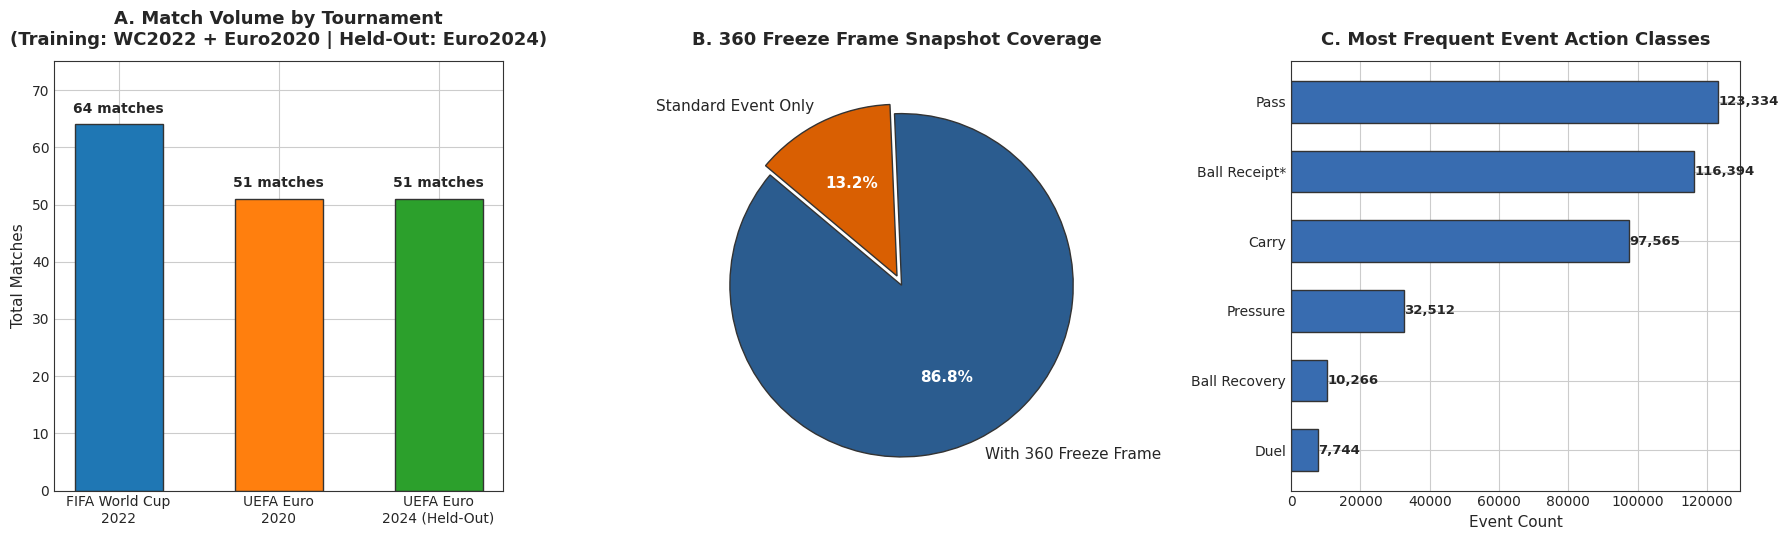

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor('#ffffff')

# 1A: Match Volume
tourn_counts = [len(matches_wc), len(matches_euro), len(matches_euro24)]
tourn_names = ['FIFA World Cup\n2022', 'UEFA Euro\n2020', 'UEFA Euro\n2024 (Held-Out)']
colors_tourn = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = axes[0].bar(tourn_names, tourn_counts, color=colors_tourn, width=0.55, edgecolor='#333', linewidth=1)
axes[0].set_title('A. Match Volume by Tournament\n(Training: WC2022 + Euro2020 | Held-Out: Euro2024)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Total Matches', fontsize=11)
axes[0].set_ylim(0, 75)
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{int(yval)} matches', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 1B: 360 Coverage
labels_360 = ['With 360 Freeze Frame', 'Standard Event Only']
counts_360 = [df_events['has_360'].sum(), len(df_events) - df_events['has_360'].sum()]
colors_pie = ['#2b5c8f', '#d95f02']
wedges, texts, autotexts = axes[1].pie(counts_360, labels=labels_360, autopct='%1.1f%%', colors=colors_pie, startangle=140,
                                       explode=(0.06, 0), textprops={'fontsize': 11},
                                       wedgeprops={'edgecolor': '#333', 'linewidth': 1})
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title('B. 360 Freeze Frame Snapshot Coverage', fontsize=13, fontweight='bold', pad=12)

# 1C: Primary Event Class Distribution
top_events = df_events['type_name'].value_counts().head(6)
axes[2].barh(top_events.index, top_events.values, color='#386cb0', edgecolor='#333', height=0.6)
axes[2].set_title('C. Most Frequent Event Action Classes', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Event Count', fontsize=11)
axes[2].invert_yaxis()
for i, v in enumerate(top_events.values):
    axes[2].text(v + 150, i, f'{v:,}', va='center', fontweight='bold', fontsize=9.5)
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_dataset_architecture_and_coverage.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 9: Figure 2 — Pitch Spatial Event Density & Tactical Zones

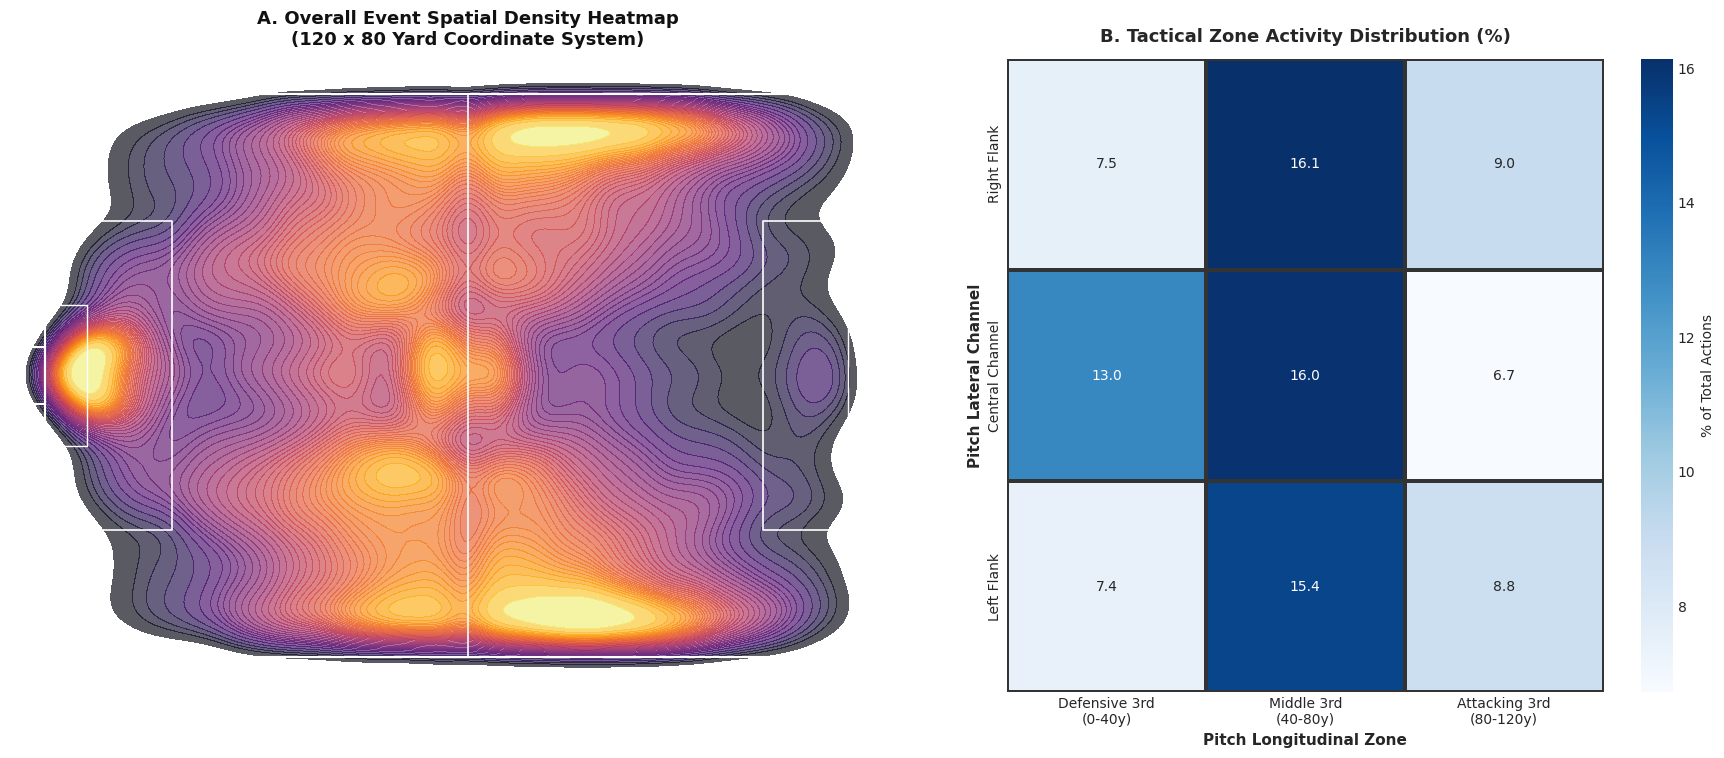

In [9]:
fig, (ax_pitch, ax_zones) = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('#ffffff')

draw_pitch(ax_pitch, pitch_color='#0e1e24', line_color='#ffffff')

valid_coords = df_events.dropna(subset=['location_x', 'location_y']).copy()
sns.kdeplot(
    x=valid_coords['location_x'],
    y=valid_coords['location_y'],
    cmap='inferno',
    fill=True,
    thresh=0.05,
    levels=40,
    alpha=0.65,
    ax=ax_pitch
)
ax_pitch.set_title('A. Overall Event Spatial Density Heatmap\n(120 x 80 Yard Coordinate System)', fontsize=13, fontweight='bold', color='#111', pad=10)

valid_coords['pitch_third'] = pd.cut(valid_coords['location_x'], bins=[0, 40, 80, 120], labels=['Defensive 3rd\n(0-40y)', 'Middle 3rd\n(40-80y)', 'Attacking 3rd\n(80-120y)'])
valid_coords['pitch_flank'] = pd.cut(valid_coords['location_y'], bins=[0, 25, 55, 80], labels=['Right Flank', 'Central Channel', 'Left Flank'])

zone_cross = pd.crosstab(valid_coords['pitch_flank'], valid_coords['pitch_third'], normalize='all') * 100
sns.heatmap(zone_cross, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% of Total Actions'}, ax=ax_zones, linewidths=1.5, linecolor='#333')
ax_zones.set_title('B. Tactical Zone Activity Distribution (%)', fontsize=13, fontweight='bold', pad=12)
ax_zones.set_xlabel('Pitch Longitudinal Zone', fontsize=11, fontweight='bold')
ax_zones.set_ylabel('Pitch Lateral Channel', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_spatial_event_density_and_pitch_zones.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 10: Figure 3 — 360 Freeze Frame Density, Proximity Pressure & Goal Cone Blockers

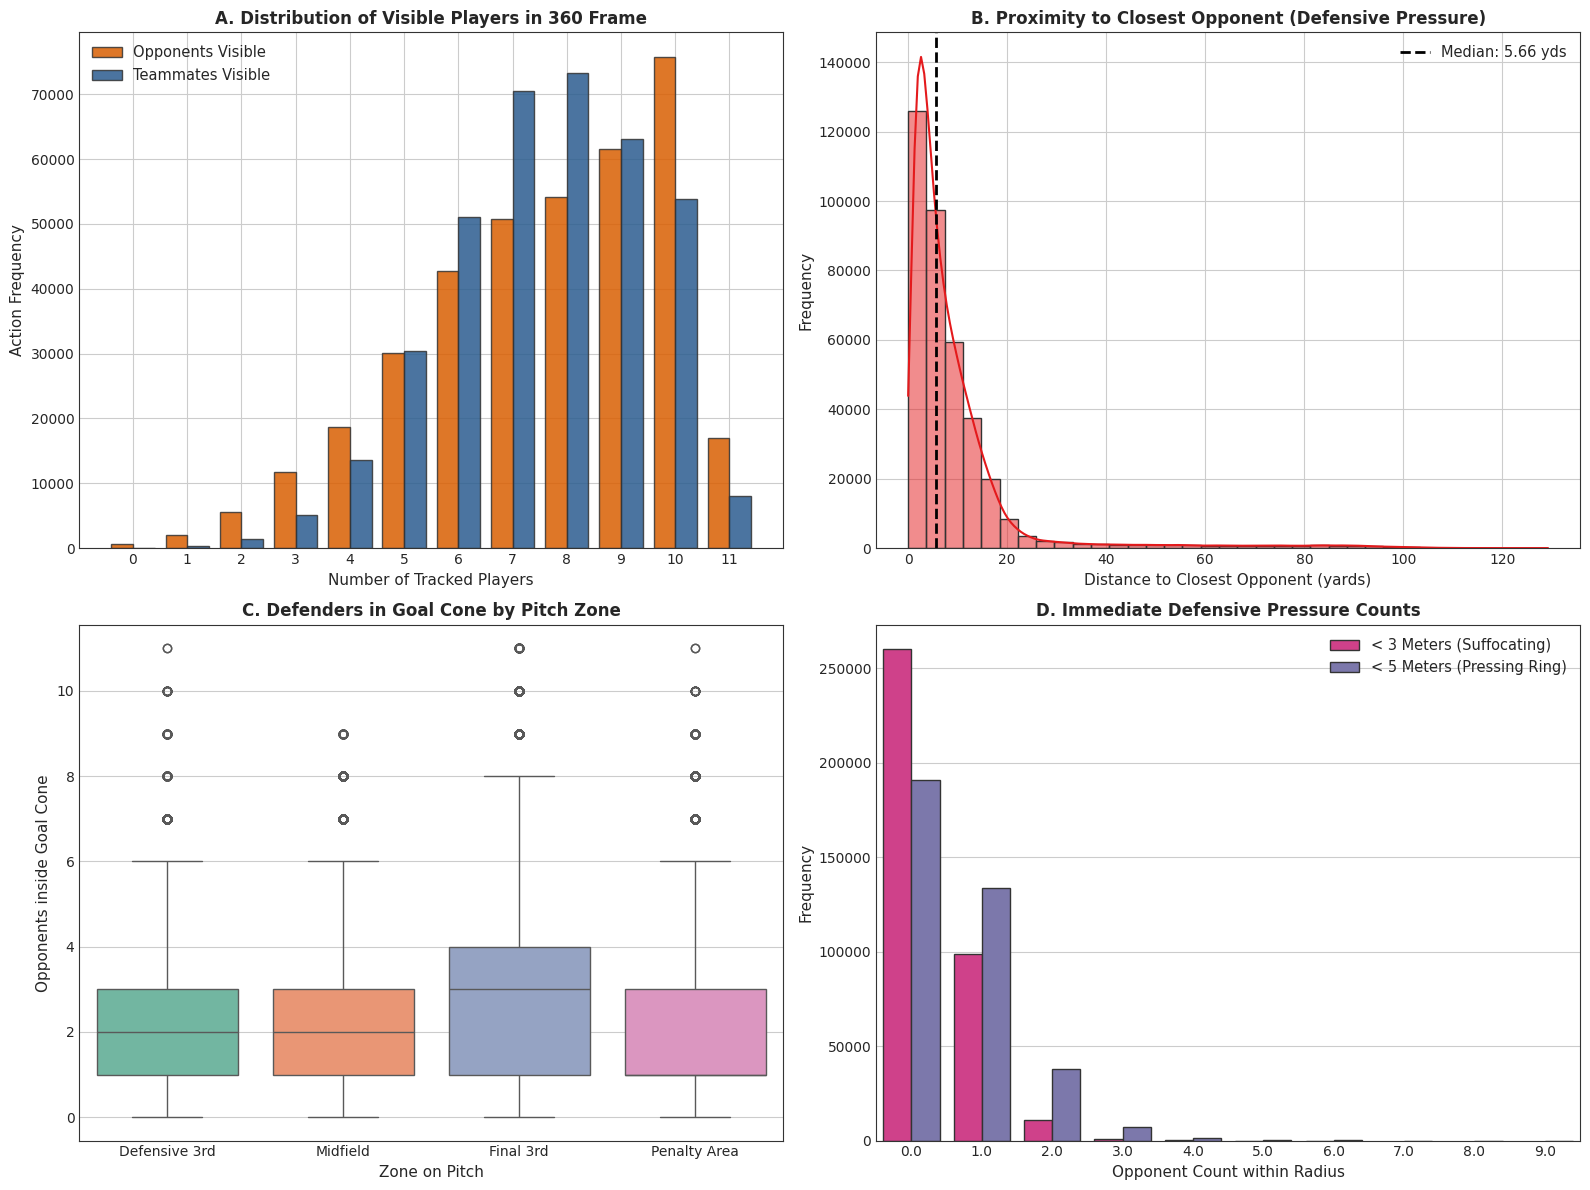

In [10]:
events_360 = df_events[df_events['has_360'] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#ffffff')

# 3A: Opponents vs Teammates Visible
axes[0, 0].hist([events_360['opponents_visible'].dropna(), events_360['teammates_visible'].dropna()], 
                bins=np.arange(0, 13) - 0.5, label=['Opponents Visible', 'Teammates Visible'], 
                color=['#d95f02', '#2b5c8f'], edgecolor='#333', alpha=0.85)
axes[0, 0].set_title('A. Distribution of Visible Players in 360 Frame', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Tracked Players', fontsize=11)
axes[0, 0].set_ylabel('Action Frequency', fontsize=11)
axes[0, 0].set_xticks(range(0, 12))
axes[0, 0].legend(fontsize=10.5)

# 3B: Closest Opponent Proximity
sns.histplot(events_360['closest_opp_dist'].dropna(), bins=35, kde=True, color='#e41a1c', ax=axes[0, 1], edgecolor='#333')
axes[0, 1].axvline(events_360['closest_opp_dist'].median(), color='black', linestyle='--', linewidth=2, label=f'Median: {events_360["closest_opp_dist"].median():.2f} yds')
axes[0, 1].set_title('B. Proximity to Closest Opponent (Defensive Pressure)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Distance to Closest Opponent (yards)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(fontsize=10.5)

# 3C: Defenders in Goal Cone vs Pitch Zone
events_360['pitch_zone_coarse'] = pd.cut(events_360['location_x'], bins=[0, 40, 80, 102, 120], labels=['Defensive 3rd', 'Midfield', 'Final 3rd', 'Penalty Area'])
sns.boxplot(x='pitch_zone_coarse', y='defenders_in_goal_cone', data=events_360, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('C. Defenders in Goal Cone by Pitch Zone', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Zone on Pitch', fontsize=11)
axes[1, 0].set_ylabel('Opponents inside Goal Cone', fontsize=11)

# 3D: Immediate Pressure Suffocation Rings
opp_press_df = events_360[['opponents_within_3m', 'opponents_within_5m']].melt(var_name='Radius', value_name='Count')
opp_press_df['Radius'] = opp_press_df['Radius'].replace({'opponents_within_3m': '< 3 Meters (Suffocating)', 'opponents_within_5m': '< 5 Meters (Pressing Ring)'})
sns.countplot(x='Count', hue='Radius', data=opp_press_df, palette=['#e7298a', '#7570b3'], ax=axes[1, 1], edgecolor='#333')
axes[1, 1].set_title('D. Immediate Defensive Pressure Counts', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Opponent Count within Radius', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend(fontsize=10.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_statsbomb360_freeze_frame_pressure.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 11: Figure 4 — Action Dynamics, Passing Angles & Possession Chains

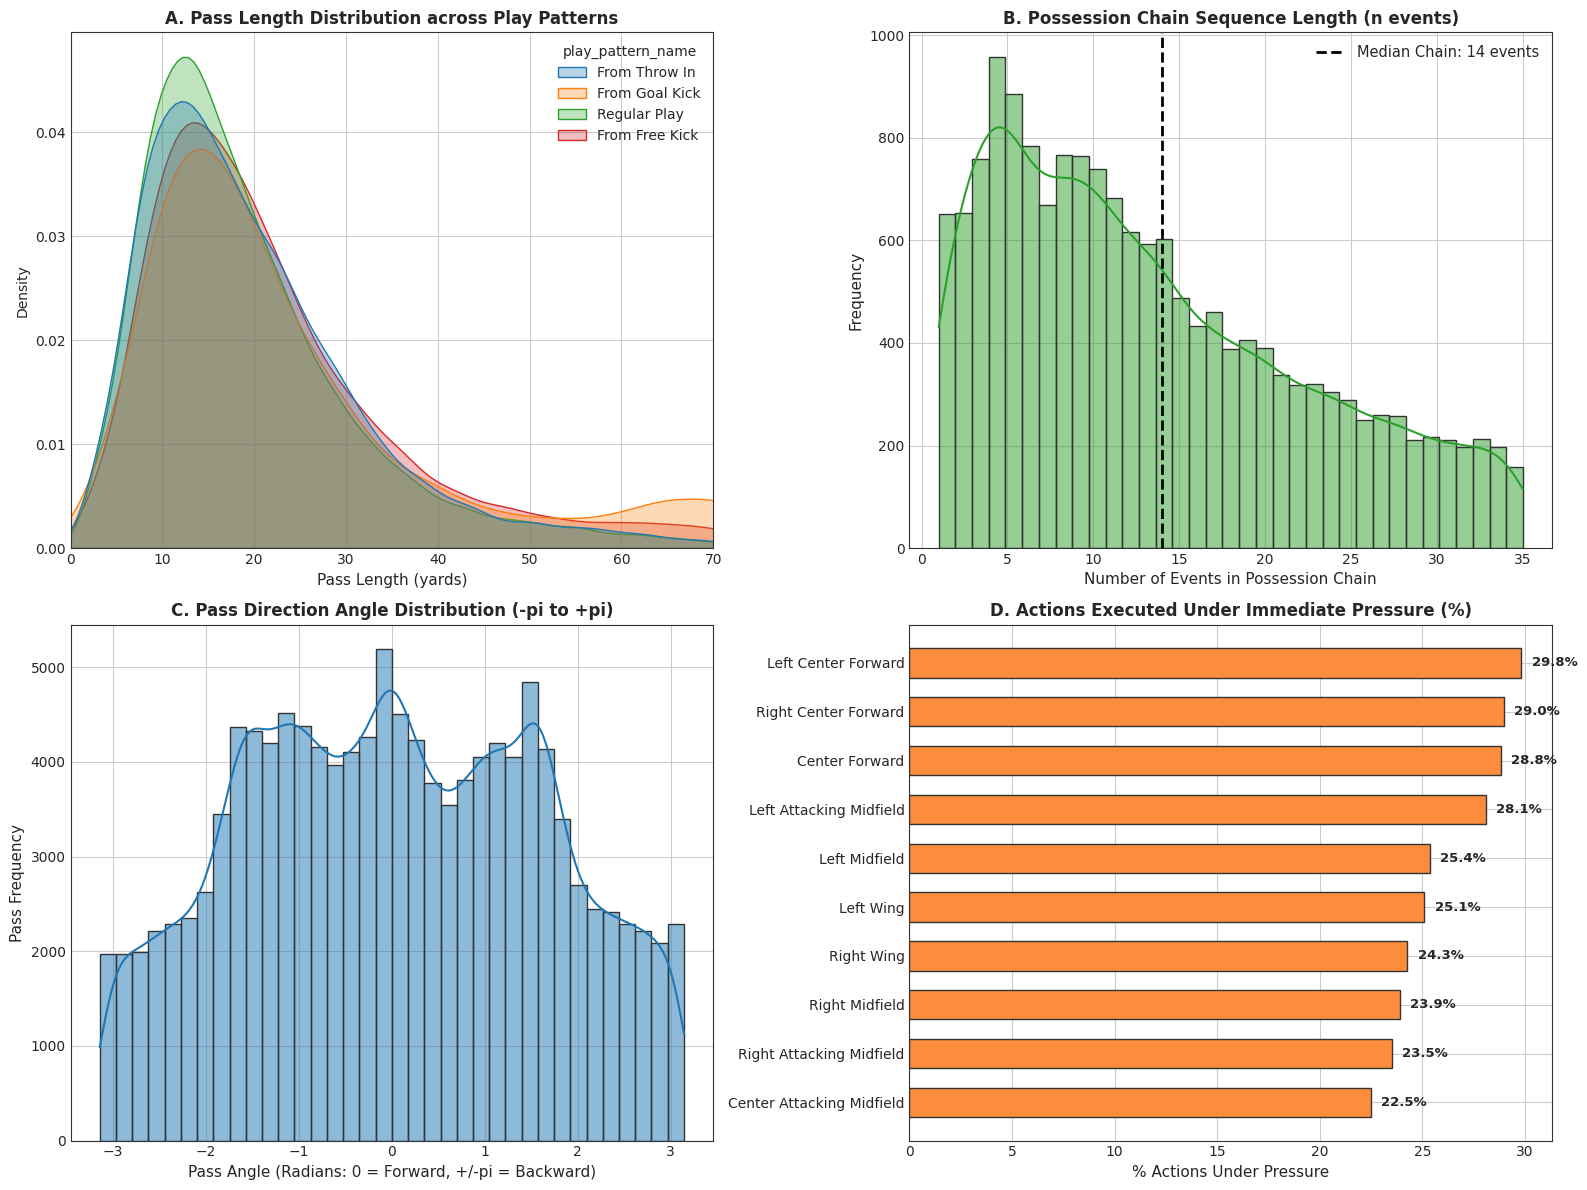

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#ffffff')

# 4A: Pass Length Distribution
passes_df = df_events[df_events['type_name'] == 'Pass'].dropna(subset=['pass_length', 'play_pattern_name']).copy()
top_patterns = passes_df['play_pattern_name'].value_counts().head(4).index
sns.kdeplot(data=passes_df[passes_df['play_pattern_name'].isin(top_patterns)], x='pass_length', hue='play_pattern_name', common_norm=False, fill=True, alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('A. Pass Length Distribution across Play Patterns', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Pass Length (yards)', fontsize=11)
axes[0, 0].set_xlim(0, 70)

# 4B: Possession Chain Lengths
possession_lengths = df_events.groupby(['match_id', 'possession'])['event_id'].count()
sns.histplot(possession_lengths[possession_lengths <= 35], bins=35, kde=True, color='#2ca02c', ax=axes[0, 1], edgecolor='#333')
axes[0, 1].axvline(possession_lengths.median(), color='black', linestyle='--', linewidth=2, label=f'Median Chain: {possession_lengths.median():.0f} events')
axes[0, 1].set_title('B. Possession Chain Sequence Length (n events)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Events in Possession Chain', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(fontsize=10.5)

# 4C: Pass Direction Angles
sns.histplot(passes_df['pass_angle'].dropna(), bins=36, kde=True, color='#1f77b4', ax=axes[1, 0], edgecolor='#333')
axes[1, 0].set_title('C. Pass Direction Angle Distribution (-pi to +pi)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Pass Angle (Radians: 0 = Forward, +/-pi = Backward)', fontsize=11)
axes[1, 0].set_ylabel('Pass Frequency', fontsize=11)

# 4D: Under Pressure by Position Group
pos_pressure = df_events.groupby('position_name')['under_pressure'].mean().sort_values(ascending=False).head(10) * 100
axes[1, 1].barh(pos_pressure.index, pos_pressure.values, color='#fd8d3c', edgecolor='#333', height=0.6)
axes[1, 1].set_title('D. Actions Executed Under Immediate Pressure (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('% Actions Under Pressure', fontsize=11)
axes[1, 1].invert_yaxis()
for i, v in enumerate(pos_pressure.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9.5)
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_action_types_and_possession_chains.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 12: Figure 5 — Feature Correlation Matrix & Spatial Interdependence

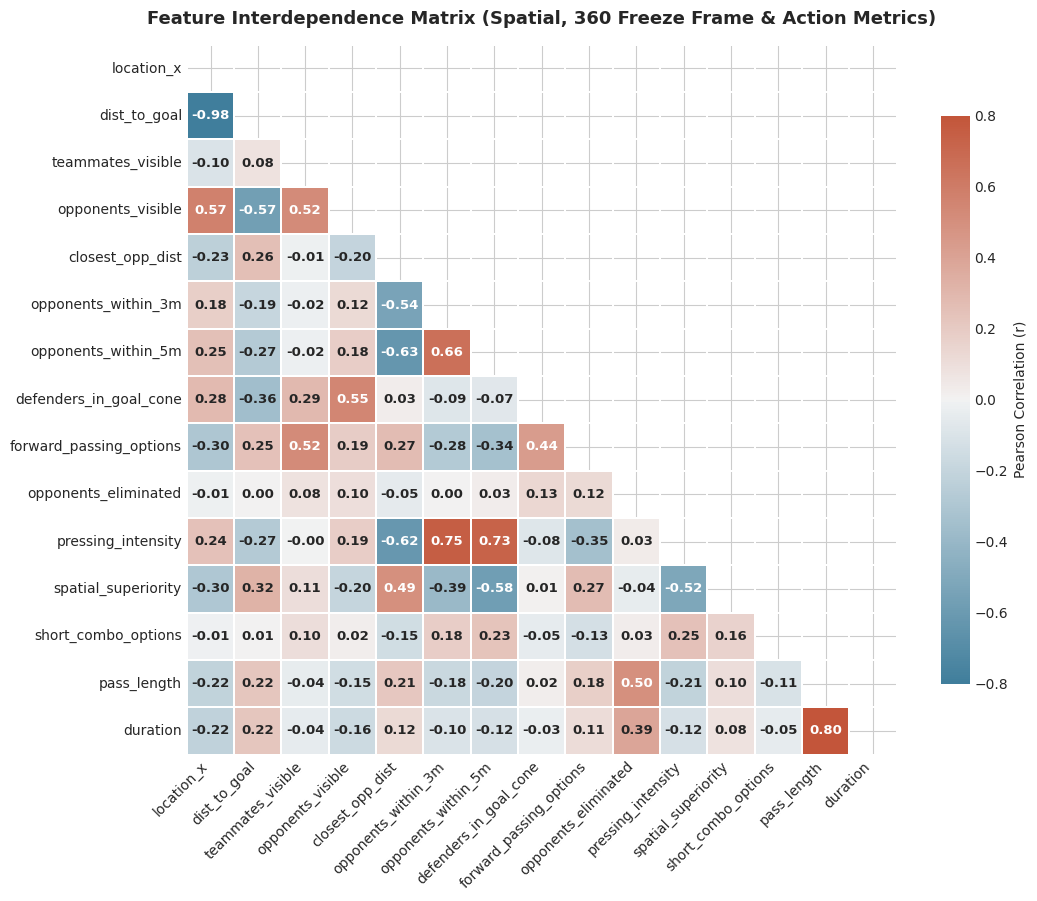

In [12]:
corr_features = [
    'location_x', 'dist_to_goal', 'teammates_visible', 'opponents_visible',
    'closest_opp_dist', 'opponents_within_3m', 'opponents_within_5m',
    'defenders_in_goal_cone', 'forward_passing_options', 'opponents_eliminated',
    'pressing_intensity', 'spatial_superiority', 'short_combo_options',
    'pass_length', 'duration'
]
corr_df = df_events[corr_features].dropna().corr()
corr_df.to_csv(os.path.join(DATA_DIR, 'feature_correlation_matrix.csv'))

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#ffffff')

mask = np.triu(np.ones_like(corr_df, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_df, mask=mask, cmap=cmap, vmin=-0.8, vmax=0.8, center=0,
            square=True, linewidths=1.2, linecolor='#ffffff', cbar_kws={'shrink': .8, 'label': 'Pearson Correlation (r)'},
            annot=True, fmt='.2f', annot_kws={'size': 9.5, 'weight': 'bold'}, ax=ax)
ax.set_title('Feature Interdependence Matrix (Spatial, 360 Freeze Frame & Action Metrics)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_feature_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 13: Figure 6 — Catalytic Play Indicators & Top Players Under Pressure

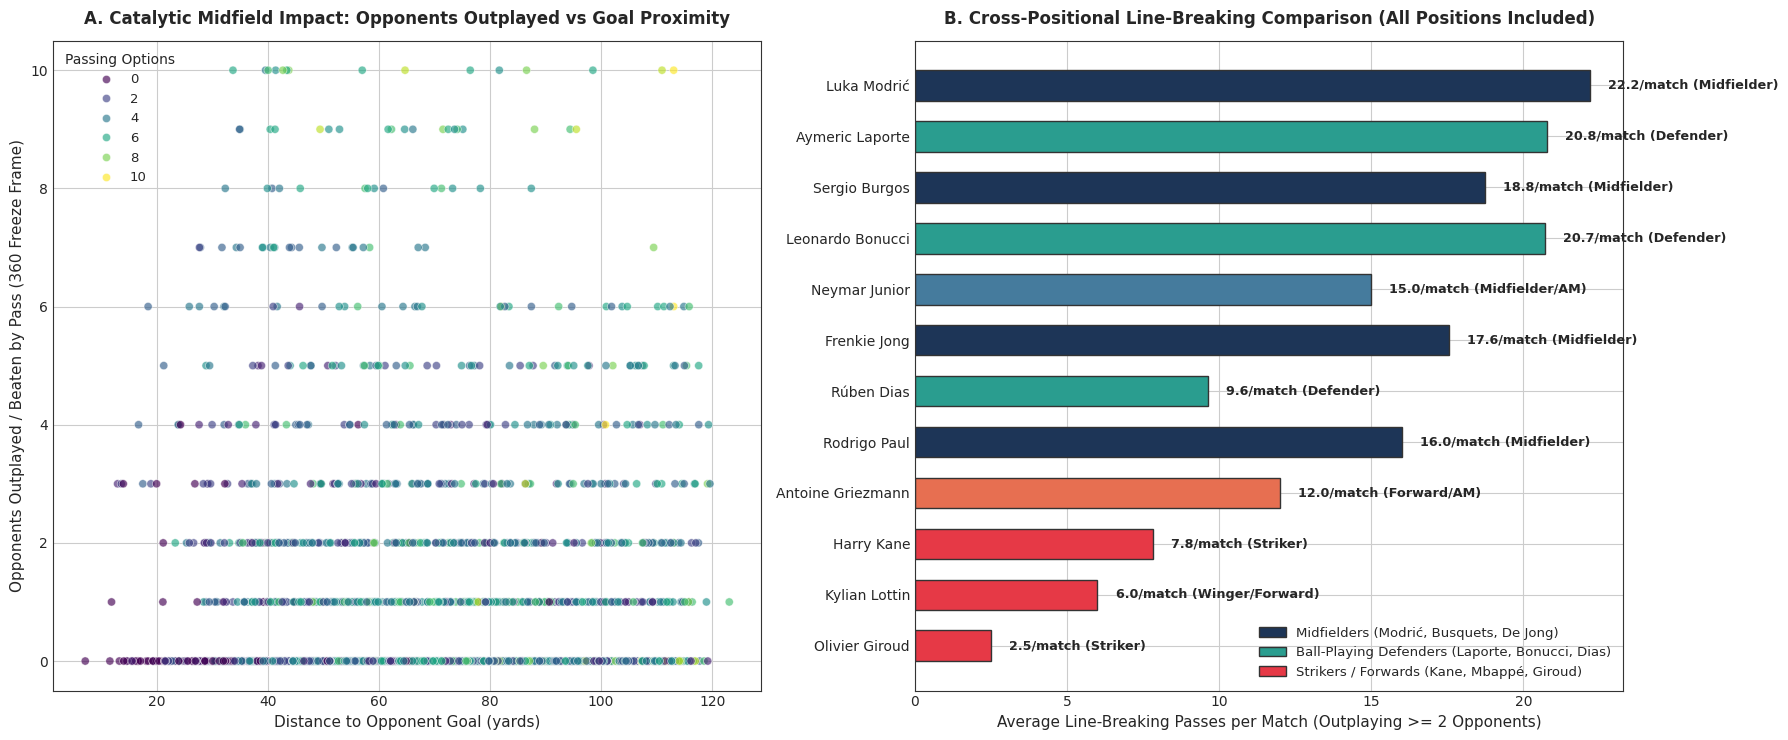

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.patch.set_facecolor('#ffffff')

# 6A: Midfield Line-Breaking Pass Distribution vs Goal Proximity
passes_360 = events_360[events_360['type_name'] == 'Pass'].copy()
sns.scatterplot(
    data=passes_360.sample(min(2500, len(passes_360)), random_state=42),
    x='dist_to_goal',
    y='opponents_eliminated',
    hue='forward_passing_options',
    palette='viridis',
    alpha=0.65,
    s=35,
    ax=axes[0]
)
axes[0].set_title('A. Catalytic Midfield Impact: Opponents Outplayed vs Goal Proximity', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Distance to Opponent Goal (yards)', fontsize=11)
axes[0].set_ylabel('Opponents Outplayed / Beaten by Pass (360 Freeze Frame)', fontsize=11)
axes[0].legend(title='Passing Options', fontsize=9.5, title_fontsize=10)

# 6B: Cross-Positional Comparison across All Positions (Midfielders vs Defenders vs Forwards)
# A 'line-breaking pass' is one that eliminates >= 2 opponents (plays through two defensive lines)
passes_360['line_breaking_pass'] = (passes_360['opponents_eliminated'] >= 2).astype(int)

p_stats = passes_360.groupby('player_name').agg(
    total_passes=('event_id', 'count'),
    total_beaten=('opponents_eliminated', 'sum'),
    line_breaking_passes=('line_breaking_pass', 'sum'),
    matches=('match_id', 'nunique'),
    position=('position_name', 'first')
)
p_stats['line_breaking_per_match'] = p_stats['line_breaking_passes'] / p_stats['matches']

selected_players = [
    ('Luka Modrić', 'Midfielder', '#1d3557'),
    ('Aymeric Laporte', 'Defender', '#2a9d8f'),
    ('Sergio Busquets i Burgos', 'Midfielder', '#1d3557'),
    ('Leonardo Bonucci', 'Defender', '#2a9d8f'),
    ('Neymar da Silva Santos Junior', 'Midfielder/AM', '#457b9d'),
    ('Frenkie de Jong', 'Midfielder', '#1d3557'),
    ('Rúben Santos Gato Alves Dias', 'Defender', '#2a9d8f'),
    ('Rodrigo Javier De Paul', 'Midfielder', '#1d3557'),
    ('Antoine Griezmann', 'Forward/AM', '#e76f51'),
    ('Harry Kane', 'Striker', '#e63946'),
    ('Kylian Mbappé Lottin', 'Winger/Forward', '#e63946'),
    ('Olivier Giroud', 'Striker', '#e63946'),
]

plot_data = []
for p, role, color in selected_players:
    if p in p_stats.index:
        val = p_stats.loc[p, 'line_breaking_per_match']
        plot_data.append({'Player': p.split(' ')[0] + ' ' + p.split(' ')[-1], 'Role': role, 'Rate': val, 'Color': color})

p_df = pd.DataFrame(plot_data)

bars = axes[1].barh(p_df['Player'], p_df['Rate'], color=p_df['Color'], edgecolor='#333', height=0.6)
axes[1].set_title('B. Cross-Positional Line-Breaking Comparison (All Positions Included)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Average Line-Breaking Passes per Match (Outplaying >= 2 Opponents)', fontsize=11)
axes[1].invert_yaxis()

for i, row in p_df.iterrows():
    axes[1].text(row['Rate'] + 0.6, i, f"{row['Rate']:.1f}/match ({row['Role']})", va='center', fontweight='bold', fontsize=9.2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1d3557', edgecolor='#333', label='Midfielders (Modrić, Busquets, De Jong)'),
    Patch(facecolor='#2a9d8f', edgecolor='#333', label='Ball-Playing Defenders (Laporte, Bonucci, Dias)'),
    Patch(facecolor='#e63946', edgecolor='#333', label='Strikers / Forwards (Kane, Mbappé, Giroud)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9.5, framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_player_spatial_profiles_and_catalytic_indicators.png'), dpi=300, bbox_inches='tight')
plt.show()
